<a href="https://colab.research.google.com/github/varun0852/for-study/blob/master/decision_tree_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import preprocessing
import matplotlib.pyplot as plt
import collections

In [ ]:
churn_1 = pd.read_csv("Bank Customer Churn Prediction.csv")
churn_1

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
x = churn_1.drop(columns=['churn', "customer_id"])
y = churn_1['churn']

In [ ]:
label_encoder = preprocessing.LabelEncoder()
x['country']= label_encoder.fit_transform(x['country'])
x['gender']= label_encoder.fit_transform(x['gender'])
x

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64
9996,516,0,1,35,10,57369.61,1,1,1,101699.77
9997,709,0,0,36,7,0.00,1,0,1,42085.58
9998,772,1,1,42,3,75075.31,2,1,0,92888.52


In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = DecisionTreeClassifier()
model.fit(xtrain, ytrain)

DecisionTreeClassifier()

In [ ]:
ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

In [ ]:
ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

In [ ]:
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  1.0
testing accuracy :  0.7765


In [ ]:
confusion_matrix(ytest, ytest_predictions)

array([[1350,  243],
       [ 204,  203]], dtype=int64)

In [ ]:
print(classification_report(ytest, ytest_predictions))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1593
           1       0.46      0.50      0.48       407

    accuracy                           0.78      2000
   macro avg       0.66      0.67      0.67      2000
weighted avg       0.78      0.78      0.78      2000



In [ ]:
roc_auc_score(ytest, ytest_predictions)

0.6731145629450714

In [ ]:
model.feature_importances_

array([0.14597933, 0.02920252, 0.01957403, 0.23488483, 0.0738634 ,
       0.15581416, 0.11781013, 0.01556532, 0.05693323, 0.15037305])

In [ ]:
features = {}
for i,j in zip(xtrain.columns, model.feature_importances_):
    features[i] = j


features

{'credit_score': 0.14597932742482267,
 'country': 0.029202522239039876,
 'gender': 0.019574031931038075,
 'age': 0.23488483434398658,
 'tenure': 0.07386339648418122,
 'balance': 0.15581415950193928,
 'products_number': 0.1178101296437991,
 'credit_card': 0.015565318386564693,
 'active_member': 0.05693322867219431,
 'estimated_salary': 0.1503730513724341}

In [ ]:
x = churn_1[["age", "estimated_salary", "balance", "credit_score", "products_number"]]
y = churn_1["churn"]

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = DecisionTreeClassifier()
model.fit(xtrain, ytrain)

DecisionTreeClassifier()

In [ ]:
ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

In [ ]:
ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

In [ ]:
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  1.0
testing accuracy :  0.7585


In [ ]:
roc_auc_score(ytest, ytest_predictions)

0.6371201710184761

In [ ]:
# max_depth =10, min_samples_leaf=100, min_samples_split=200, max_leaf_nodes=35,

model = DecisionTreeClassifier(max_depth =10, min_samples_leaf=100, min_samples_split=200, max_leaf_nodes=35)
model.fit(xtrain, ytrain)

ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.846625
testing accuracy :  0.8415


In [ ]:
model = DecisionTreeClassifier(max_depth = 6, min_samples_split=50, min_samples_leaf=70, criterion='entropy')
model.fit(xtrain, ytrain)

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=70,
                       min_samples_split=50)

In [ ]:
ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)
ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.84175
testing accuracy :  0.833


In [ ]:
confusion_matrix(ytest, ytest_predictions)

array([[1470,  123],
       [ 211,  196]])

In [ ]:
print(classification_report(ytest, ytest_predictions))

              precision    recall  f1-score   support

           0       0.87      0.92      0.90      1593
           1       0.61      0.48      0.54       407

    accuracy                           0.83      2000
   macro avg       0.74      0.70      0.72      2000
weighted avg       0.82      0.83      0.83      2000



In [ ]:
roc_auc_score(ytest, ytest_predictions)

0.702179837773058

In [ ]:
param_grid = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'splitter' : ['best', 'random'],
    'max_depth' : [2,5,7,9,11]
}
decision_tree = DecisionTreeClassifier()
gscv = GridSearchCV(estimator=decision_tree, cv=5, param_grid = param_grid, verbose = 3)
gscv.fit(xtrain, ytrain)
print(gscv.best_params_)
print(gscv.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END criterion=gini, max_depth=2, splitter=best;, score=0.819 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=2, splitter=best;, score=0.822 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=2, splitter=best;, score=0.812 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=2, splitter=best;, score=0.821 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=2, splitter=best;, score=0.821 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=2, splitter=random;, score=0.803 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=2, splitter=random;, score=0.822 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=2, splitter=random;, score=0.812 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=2, splitter=random;, score=0.821 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=2, splitter=random;, score=0.804 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth

In [ ]:
model = DecisionTreeClassifier(criterion='log_loss', max_depth=5, splitter='best')
model.fit(xtrain, ytrain)

DecisionTreeClassifier(criterion='log_loss', max_depth=5)

In [ ]:
ytrain_predictions = model.predict(xtrain)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

In [ ]:
ytest_predictions = model.predict(xtest)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

In [ ]:
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.843625
testing accuracy :  0.836


In [ ]:
confusion_matrix(ytest, ytest_predictions)

array([[1511,   82],
       [ 246,  161]], dtype=int64)

In [ ]:
print(classification_report(ytest, ytest_predictions))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1593
           1       0.66      0.40      0.50       407

    accuracy                           0.84      2000
   macro avg       0.76      0.67      0.70      2000
weighted avg       0.82      0.84      0.82      2000



In [ ]:
roc_auc_score(ytest, ytest_predictions)

0.6720510957799093

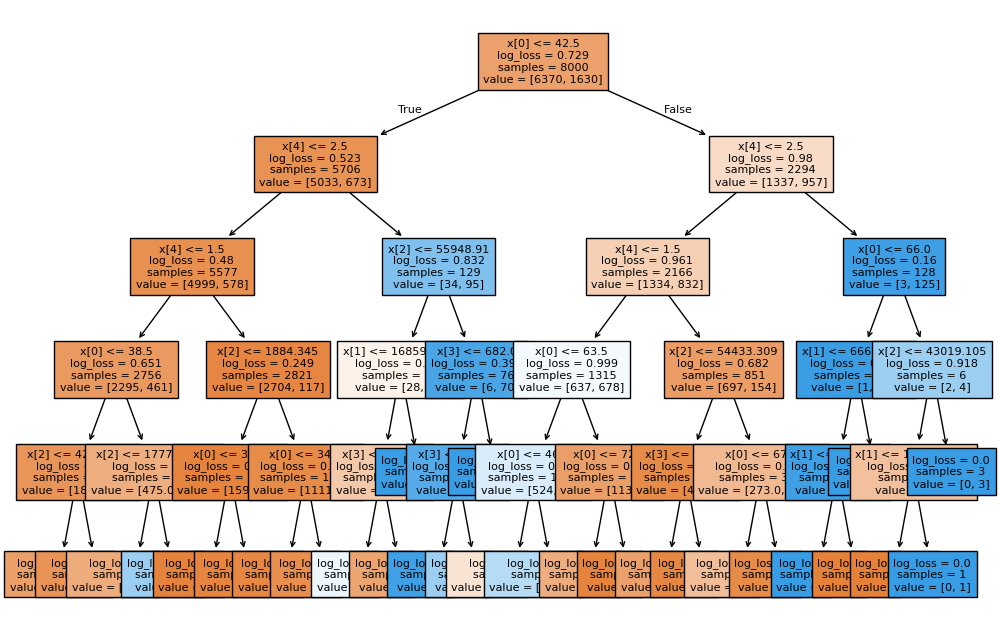

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(model, filled=True, fontsize=8)
plt.show()

In [ ]:
model.feature_importances_

array([0.45426379, 0.01366015, 0.08187245, 0.014121  , 0.43608261])

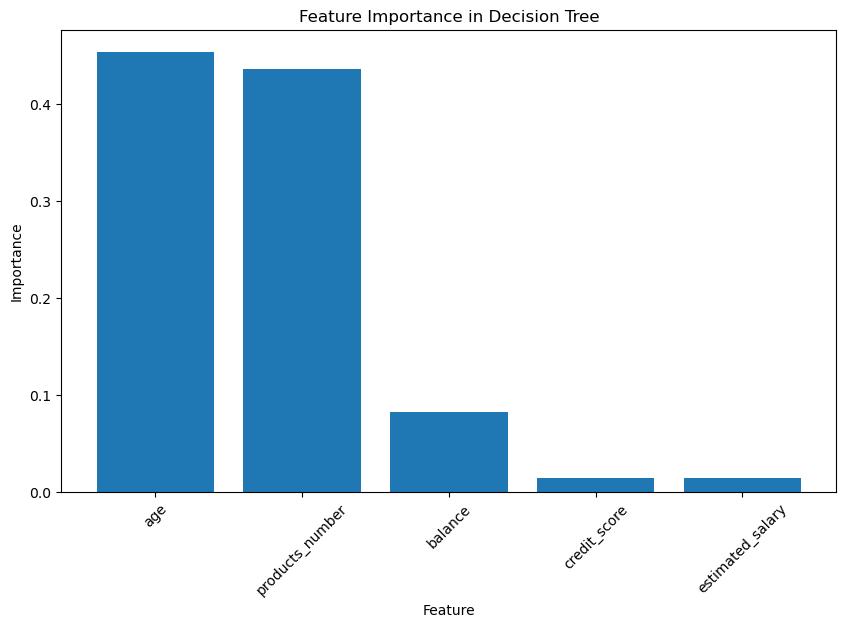

In [ ]:
feature_names = xtrain.columns
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_feature_names = [feature_names[i] for i in indices]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance in Decision Tree")
plt.bar(range(xtrain.shape[1]), importances[indices], align='center')
plt.xticks(range(xtrain.shape[1]), sorted_feature_names, rotation=45)
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.show()

In [ ]:
xtrain1

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary
2151,753,0,1,57,7,0.00,1,1,0,159475.08
8392,739,1,1,32,3,102128.27,1,1,0,63981.37
5006,755,1,0,37,0,113865.23,2,1,1,117396.25
4117,561,0,1,37,5,0.00,2,1,0,83093.25
7182,692,1,1,49,6,110540.43,2,0,1,107472.99
...,...,...,...,...,...,...,...,...,...,...
4555,688,2,0,35,6,0.00,1,1,0,25488.43
4644,712,2,1,74,5,0.00,2,0,0,151425.82
8942,667,0,0,37,9,71786.90,2,1,1,67734.79
2935,687,2,1,35,8,100988.39,2,1,0,22247.27


In [ ]:
xtrain_new = xtrain1[["age", "products_number", "active_member", "balance", "country"]]

In [ ]:
xtest_new = xtest1[["age", "products_number", "active_member", "balance", "country"]]

In [ ]:
model = DecisionTreeClassifier()
model.fit(xtrain_new, ytrain)

DecisionTreeClassifier()

In [ ]:
ytrain_predictions = model.predict(xtrain_new)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

In [ ]:
ytest_predictions = model.predict(xtest_new)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

In [ ]:
print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.975625
testing accuracy :  0.814


In [ ]:
param_grid = {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'splitter' : ['best', 'random'],
    'max_depth' : [2,5,7,9,11]
}
decision_tree = DecisionTreeClassifier()
gscv = GridSearchCV(estimator=decision_tree, cv=5, param_grid = param_grid, verbose = 3)
gscv.fit(xtrain_new, ytrain)
print(gscv.best_params_)
print(gscv.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END criterion=gini, max_depth=2, splitter=best;, score=0.824 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=2, splitter=best;, score=0.842 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=2, splitter=best;, score=0.821 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=2, splitter=best;, score=0.828 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=2, splitter=best;, score=0.836 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=2, splitter=random;, score=0.803 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=2, splitter=random;, score=0.799 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=2, splitter=random;, score=0.810 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=2, splitter=random;, score=0.821 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=2, splitter=random;, score=0.804 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth

In [ ]:
model = DecisionTreeClassifier(criterion='gini', max_depth=7, splitter='best')
model.fit(xtrain_new, ytrain)

DecisionTreeClassifier(max_depth=7)

In [ ]:
ytrain_predictions = model.predict(xtrain_new)
training_accuracy = accuracy_score(ytrain, ytrain_predictions)

ytest_predictions = model.predict(xtest_new)
testing_accuracy = accuracy_score(ytest, ytest_predictions)

print("training accuracy : ", training_accuracy)
print("testing accuracy : ", testing_accuracy)

training accuracy :  0.86825
testing accuracy :  0.86


In [ ]:
roc_auc_score(ytest, ytest_predictions)

0.6999218016167169

In [ ]:
xtrain_new

,age,products_number,active_member,balance,country
2151,57,1,0,0.00,0
8392,32,1,0,102128.27,1
5006,37,2,1,113865.23,1
4117,37,2,0,0.00,0
7182,49,2,1,110540.43,1
...,...,...,...,...,...
4555,35,1,0,0.00,2
4644,74,2,0,0.00,2
8942,37,2,1,71786.90,0
2935,35,2,0,100988.39,2


In [ ]:
ytrain_predictions

array([1, 0, 0, ..., 0, 0, 0], dtype=int64)

In [ ]:
ytrain

2151    1
8392    1
5006    0
4117    0
7182    0
       ..
4555    1
4644    0
8942    0
2935    0
6206    0
Name: churn, Length: 8000, dtype: int64